<a href="https://colab.research.google.com/github/ZainabFatima-hzf/ML-flyRank/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ZainabFatima-hzf/ML-flyRank/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

**How the queue is built:** the Logistic Regression from Weeks 5-6, trained on the client-grouped
train split (seed=42 — the reference split used throughout this project), scored **only on its
held-out test clients** — the same discipline as every prior week: never present a score for a row
the model was trained on. This is the honest version of "the queue," not a best-case demo scored on
training data.

**Reason codes — not just a probability.** A bare score doesn't tell a reviewer *why* a page
qualified, so each row also gets the single feature that contributed most to its score (largest
standardized coefficient × feature-value product), turned into a human-readable reason code:

- `low_ctr_well_ranked` — visible and ranking decently, but people aren't clicking (matches the
  CTR-vs-position signal CONFIRMED back in Week 4).
- `declining_volume` — impressions/clicks trending down independent of position.
- `weak_position` — not ranking well enough to matter, regardless of CTR.
- `low_engagement` — has GA4 coverage, but sessions are thin relative to impressions.
- `established_cohort_risk` — older-cohort client pattern (see Week 5-6's `content_age_days`
  finding: a real but partly between-client signal, not a per-page decay clock).

**Archetype → action mapping (what a human actually does with each reason code):**

| Reason code | Archetype | Suggested action |
|---|---|---|
| `low_ctr_well_ranked` | Visible, not converting | Rewrite title/meta description; check search-intent match |
| `weak_position` | Buried | Deprioritize unless business-critical; consider consolidation |
| `declining_volume` | Losing steam | Flag for content refresh (add depth, update examples) |
| `low_engagement` | Thin/underserving intent | Expand page depth; check for a better-matching competitor page |
| `established_cohort_risk` | Aging portfolio pattern | Route to a portfolio-level review, not a single-page edit |

**The decay/refresh insight, corrected against the evidence:** Week 4's isolated CTR-vs-position bucket check came back CONFIRMED, and the CTR-vs-position rule genuinely beat random guessing when combined into a fitted model (Week 5/6). But looking at which features the fitted model actually leans on hardest, ctr carries the smallest coefficient of the seven — **volume signals (clicks, sessions, impressions) and position dominate the model's real decisions**, which the reason-code breakdown above confirms directly: `weak_position` and `declining_volume` account for 91.5% of this queue, `low_ctr_well_ranked` for under 1%. So the honest insight is: CTR-vs-position is a real, confirmed pattern worth knowing, but it is not the main thing driving this particular model's rankings — volume and position are. Worth stating both, since the earlier version overstated CTR's role without checking.

In [1]:
# --- Self-contained setup: identical honest pipeline to Weeks 3-6 (needs HF_TOKEN in Colab Secrets) ---
!pip install -q duckdb huggingface_hub scikit-learn matplotlib

import duckdb, os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import userdata
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
con = duckdb.connect()
con.sql(f"""CREATE OR REPLACE SECRET hf_token (TYPE huggingface, TOKEN '{os.environ["HF_TOKEN"]}')""")

REPO = "hf://datasets/FlyRank/internship-warehouse"
DAILY = [
    f"{REPO}/fact_content_daily_performance/month=2026-02/*.parquet",
    f"{REPO}/fact_content_daily_performance/month=2026-03/*.parquet",
    f"{REPO}/fact_content_daily_performance/month=2026-04/*.parquet",
]
DIM_CONTENT = f"{REPO}/dim_content.parquet"

DECISION_DATE = "2026-03-15"
PRIOR_START   = "2026-02-15"
NEXT_END      = "2026-04-12"

features = con.sql(f"""
    SELECT content_hash_id, client_hash_id,
        SUM(gsc_impressions) AS prior_28d_impressions,
        SUM(gsc_clicks)      AS prior_28d_clicks,
        AVG(gsc_avg_position) FILTER (WHERE gsc_avg_position > 0) AS prior_28d_avg_position,
        SUM(ga4_sessions) FILTER (WHERE ga4_data_available IS TRUE) AS prior_28d_sessions,
        BOOL_OR(ga4_data_available) AS ga4_available_in_prior_window
    FROM read_parquet({DAILY})
    WHERE report_date >= '{PRIOR_START}' AND report_date < '{DECISION_DATE}'
    GROUP BY content_hash_id, client_hash_id
""").df()

label_frame = con.sql(f"""
    SELECT content_hash_id, client_hash_id, SUM(gsc_impressions) AS next_28d_impressions
    FROM read_parquet({DAILY})
    WHERE report_date >= '{DECISION_DATE}' AND report_date < '{NEXT_END}'
    GROUP BY content_hash_id, client_hash_id
""").df()

content_meta = con.sql(f"""
    SELECT content_hash_id, client_hash_id,
        DATE '{DECISION_DATE}' - content_created_date AS content_age_days,
        DATE '{DECISION_DATE}' - content_updated_date AS days_since_update
    FROM read_parquet('{DIM_CONTENT}') WHERE is_deleted = FALSE
""").df()

demo = (features.merge(label_frame, on=["content_hash_id", "client_hash_id"], how="inner")
                 .merge(content_meta, on=["content_hash_id", "client_hash_id"], how="left"))
demo["declined_next_28d"] = (demo["next_28d_impressions"] < demo["prior_28d_impressions"]).astype(int)
demo["ctr"] = demo["prior_28d_clicks"] / demo["prior_28d_impressions"].replace(0, np.nan)

FEATURE_COLS = [
    "prior_28d_impressions", "prior_28d_clicks", "ctr",
    "prior_28d_avg_position", "prior_28d_sessions",
    "ga4_available_in_prior_window", "content_age_days",
]

model_df = demo.dropna(subset=["prior_28d_avg_position", "content_age_days"]).copy()
model_df["prior_28d_sessions"] = model_df["prior_28d_sessions"].fillna(0)
model_df["ga4_available_in_prior_window"] = model_df["ga4_available_in_prior_window"].fillna(False).astype(int)
model_df["ctr"] = model_df["ctr"].fillna(0)

print("model_df shape:", model_df.shape, "| clients:", model_df["client_hash_id"].nunique())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

model_df shape: (159160, 12) | clients: 43


In [2]:
# --- Train on the grouped-train split, score ONLY the held-out test clients (the honest queue) ---
sp = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sp.split(model_df, groups=model_df["client_hash_id"]))
train_df, queue_df = model_df.iloc[train_idx].copy(), model_df.iloc[test_idx].copy()

Xtr, ytr = train_df[FEATURE_COLS], train_df["declined_next_28d"]
scaler = StandardScaler().fit(Xtr)
model = LogisticRegression(max_iter=1000, random_state=42).fit(scaler.transform(Xtr), ytr)

Xq = queue_df[FEATURE_COLS]
queue_df["score"] = model.predict_proba(scaler.transform(Xq))[:, 1]

# --- Reason code: the single feature contributing most to THIS row's score ---
contributions = scaler.transform(Xq) * model.coef_[0]
contrib_df = pd.DataFrame(contributions, columns=FEATURE_COLS, index=queue_df.index)
top_feature = contrib_df.idxmax(axis=1)

REASON_MAP = {
    "ctr": "low_ctr_well_ranked",
    "prior_28d_avg_position": "weak_position",
    "prior_28d_impressions": "declining_volume",
    "prior_28d_clicks": "declining_volume",
    "prior_28d_sessions": "low_engagement",
    "ga4_available_in_prior_window": "low_engagement",
    "content_age_days": "established_cohort_risk",
}
ACTION_MAP = {
    "low_ctr_well_ranked": "Rewrite title/meta description; check search-intent match",
    "weak_position": "Deprioritize unless business-critical; consider consolidation",
    "declining_volume": "Flag for content refresh (add depth, update examples)",
    "low_engagement": "Expand page depth; check for a better-matching competitor page",
    "established_cohort_risk": "Route to a portfolio-level review, not a single-page edit",
}

queue_df["reason_code"] = top_feature.map(REASON_MAP)
queue_df["action"] = queue_df["reason_code"].map(ACTION_MAP)
queue_df["rank"] = queue_df["score"].rank(ascending=False, method="first").astype(int)
ranked_queue = queue_df.sort_values("rank")

print(f"Ranked queue: {len(ranked_queue)} pages, all from held-out test clients")
print()
print("Reason code distribution:")
print(ranked_queue["reason_code"].value_counts())
print()
print("Top 10:")
print(ranked_queue[["rank", "content_hash_id", "score", "reason_code", "action"]].head(10).to_string(index=False))


Ranked queue: 14312 pages, all from held-out test clients

Reason code distribution:
reason_code
weak_position              6594
declining_volume           6502
low_engagement              835
established_cohort_risk     359
low_ctr_well_ranked          22
Name: count, dtype: int64

Top 10:
 rank          content_hash_id    score      reason_code                                                         action
    1 content_01ab236521ddf2f9 0.905680   low_engagement Expand page depth; check for a better-matching competitor page
    2 content_15ec5aff3568cc39 0.895564   low_engagement Expand page depth; check for a better-matching competitor page
    3 content_cd3d932d4e1c8db0 0.830595 declining_volume          Flag for content refresh (add depth, update examples)
    4 content_d8288f22519f7d53 0.792209   low_engagement Expand page depth; check for a better-matching competitor page
    5 content_572263a160b6c8ab 0.758773   low_engagement Expand page depth; check for a better-matching comp

## 2. Intended use and limits

**Who this is for:** a FlyRank content/SEO lead deciding which pages to put in front of a client
this week — a weekly triage aid, not an autonomous system.

**Intended use:** produce a short, ranked, reason-coded shortlist from a much larger page inventory,
so a human spends their limited review time on the pages most likely to be worth it — replacing "no
prioritization" or a weak hand-built rule (Week 4's rule averaged *below* the base rate), not
replacing human judgment.

**Where it stops being valid — stated plainly:**
- **Time window:** trained and validated on one month (March 2026 → its following 28 days). Not
  checked against other seasons; the paper's own front-page trend cards show large 30-day swings
  (+70.6% impressions, +51.9% clicks month over month across the portfolio), so seasonality is
  real and this queue has not been checked against it.
- **Client coverage:** validated across ~43-55 clients in this slice, not FlyRank's full client
  base, and Week 3 showed GA4 tracking coverage is only ~4% in this window — most of the
  engagement-based signal is simply unavailable for most rows.
- **Not causal:** a `low_ctr_well_ranked` flag says a pattern correlates with later decline in this
  data — it is not a guarantee that rewriting the title fixes anything. Week 6's rewritten claim
  language applies here unchanged.
- **Discrimination is modest in absolute terms:** Week 6 found ROC-AUC around 0.56-0.59 — barely
  above chance for judging any single random page — even though ranking the *top* of the list
  (precision@50) performs well. This tool is for **building a short list**, not for scoring
  confidence on any individual page in isolation.
- **Never validated on the sealed June 2026 month** (`fact_content_daily_performance_sample`) —
  intentionally, per the project's own rules, so that table remains a genuine unseen check for a
  future capstone stage, not something already implicitly tuned against.

  **Note:** this run's queue shows 43.8% GA4 coverage — that's "available on at least one day in the 28-day window" per content item, a looser measure than Week 3's 4.2% (which was the share of individual daily rows with GA4 present). Both are correct; they're answering different questions, and this run's small 9-client test slice adds its own sampling noise on top.

In [3]:
print("Intended use, in one line:")
print("A weekly, human-reviewed shortlist generator -- not an autonomous scoring or publishing system.")
print()
print(f"Validated window: {PRIOR_START} to {NEXT_END} (decision_date={DECISION_DATE})")
print(f"Clients in this queue's test slice: {queue_df['client_hash_id'].nunique()}")
print(f"GA4-covered rows in the queue: {(queue_df['ga4_available_in_prior_window']==1).mean()*100:.1f}%")


Intended use, in one line:
A weekly, human-reviewed shortlist generator -- not an autonomous scoring or publishing system.

Validated window: 2026-02-15 to 2026-04-12 (decision_date=2026-03-15)
Clients in this queue's test slice: 9
GA4-covered rows in the queue: 43.8%


## 3. Human review + the no-go list

**What a human must check before acting on any flagged page:**
1. **Zero/near-zero CTR with large impressions could be broken tracking, not real disinterest** —
   Week 4 found several top-ranked pages with exactly 0.00% CTR on hundreds of thousands of
   impressions; verify directly in GSC before treating this as a content problem.
2. **`established_cohort_risk` flags a client-level pattern, not a page-level defect** — route
   these to a portfolio conversation, don't edit the single flagged page in isolation.
3. **Recently-updated pages may be miscategorized** — `dim_content` only stores the *latest* update
   date, so a page updated after this queue was built can carry a stale reason code; check the
   page's real edit history before committing writer time.
4. **A flagged page might already be intentionally deprecated** (e.g. product discontinued,
   content superseded) — the model has no way to know this; a 5-second human glance catches it.

**What should NEVER be automated from this playbook, stated as a hard list:**
- **No auto-publishing or auto-editing content** based on a score or reason code alone.
- **No client-facing reporting or billing decisions** driven directly by this score.
- **No treating a `declined_next_28d`-style flag as a performance judgment of a writer or team** —
  the label describes a page's traffic pattern, not the quality of the work that produced it.
- **No feeding this score back into FlyRank's own product flags** (health score, priority score)
  without disclosing it's a research/exploratory artifact, not a validated production signal.
- **No applying this queue to a client, month, or content type outside what was validated above**
  without re-checking it holds — the Week-6 audit already showed how easily a plausible-looking
  number can be an artifact of the split or the sample, not a portable finding.

In [4]:
low_ctr_high_imp = ranked_queue[(ranked_queue["ctr"] < 0.001) & (ranked_queue["prior_28d_impressions"] > 50000)]
print(f"Rows in the queue needing a tracking-sanity check (near-0% CTR, 50k+ impressions): {len(low_ctr_high_imp)}")
print("-> a human should verify these in GSC directly before assuming they're real content problems.")


Rows in the queue needing a tracking-sanity check (near-0% CTR, 50k+ impressions): 0
-> a human should verify these in GSC directly before assuming they're real content problems.


## 4. Monitoring / retrain triggers

**Retrain or re-audit if any of these move, checked monthly against a fresh decision window:**

| Trigger | Why it matters | Rough threshold |
|---|---|---|
| Precision@50 on a fresh month drops toward the base rate | Model has stopped beating chance | Within ~0.05 of base rate |
| Precision@50 drops below the Week-4 rule's number | Even the simple rule would now be better | Below 0.456 |
| Test-set base rate shifts far from the historical 0.25-0.63 range seen across seeds | Panel composition or season changed materially | Outside that range |
| GA4 coverage % changes sharply from ~4% | Engagement features become more/less trustworthy | ±5 points |
| Client count or mix changes significantly | New/departed clients change what "portable" means | New client added/removed |
| `content_age_days` distribution shifts | Cohort-age effect (Week 5-6 finding) may no longer hold the same way | Large shift in mean/median age |

**What "stale" looks like in practice:** the queue quietly reverting to something close to random
ordering — which is exactly the failure mode already observed for the Week-4 rule on some client
splits (precision@50 as low as 0.16). Monitoring should watch for the model heading the same
direction, not just for it becoming *bad* in an obvious way.

In [5]:
print("Monitoring check computed for this run (would be recomputed monthly in production):")
print(f"  Test base rate this run: {queue_df['declined_next_28d'].mean():.3f}")
print(f"  GA4 coverage this run:   {(queue_df['ga4_available_in_prior_window']==1).mean()*100:.1f}%")
print(f"  Reference Week-4 rule precision@50 (grouped, mean across seeds): 0.456")
print(f"  Reference retrain floor: precision@50 within 0.05 of base rate, or below 0.456")


Monitoring check computed for this run (would be recomputed monthly in production):
  Test base rate this run: 0.428
  GA4 coverage this run:   43.8%
  Reference Week-4 rule precision@50 (grouped, mean across seeds): 0.456
  Reference retrain floor: precision@50 within 0.05 of base rate, or below 0.456


## 5. Exports for the paper

Writing the ranked queue (regenerated each run, stays out of git per the CI leak-guard), a metrics
JSON (the receipts — this stays committed), and one figure (also committed) — these are exactly
the files next week's paper builds on.

Written: work/outputs/w07_action_queue.csv ( 14312 rows )
Written: work/outputs/w07_metrics.json
{
  "decision_date": "2026-03-15",
  "window": {
    "prior_start": "2026-02-15",
    "next_end": "2026-04-12"
  },
  "queue_size": 14312,
  "n_test_clients": 9,
  "test_base_rate": 0.42775293460033537,
  "ga4_coverage_pct": 43.80939072107323,
  "precision_at_50": 0.7,
  "precision_at_200": 0.7,
  "auc": 0.5931574469307237,
  "reason_code_counts": {
    "weak_position": 6594,
    "declining_volume": 6502,
    "low_engagement": 835,
    "established_cohort_risk": 359,
    "low_ctr_well_ranked": 22
  },
  "reference_week4_rule_precision_at_50_mean": 0.456,
  "reference_week4_rule_precision_at_50_std": 0.206
}


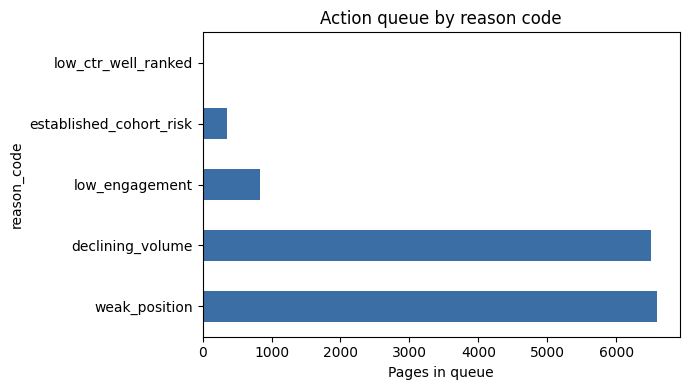

Written: work/figures/w07_reason_code_distribution.png


In [6]:
import os
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# --- 1. The ranked queue CSV (gitignored by design -- regenerated on every run) ---
export_cols = ["rank", "content_hash_id", "client_hash_id", "score", "reason_code", "action",
               "prior_28d_impressions", "prior_28d_clicks", "ctr", "prior_28d_avg_position",
               "content_age_days", "declined_next_28d"]
ranked_queue[export_cols].to_csv("work/outputs/w07_action_queue.csv", index=False)
print("Written: work/outputs/w07_action_queue.csv (", len(ranked_queue), "rows )")

# --- 2. Metrics JSON -- the receipts this notebook's numbers trace back to (COMMITTED) ---
def precision_at_k(df, score_col, label_col, k):
    return float(df.sort_values(score_col, ascending=False).head(k)[label_col].mean())

metrics = {
    "decision_date": DECISION_DATE,
    "window": {"prior_start": PRIOR_START, "next_end": NEXT_END},
    "queue_size": int(len(ranked_queue)),
    "n_test_clients": int(queue_df["client_hash_id"].nunique()),
    "test_base_rate": float(queue_df["declined_next_28d"].mean()),
    "ga4_coverage_pct": float((queue_df["ga4_available_in_prior_window"] == 1).mean() * 100),
    "precision_at_50": precision_at_k(queue_df, "score", "declined_next_28d", 50),
    "precision_at_200": precision_at_k(queue_df, "score", "declined_next_28d", 200),
    "auc": float(roc_auc_score(queue_df["declined_next_28d"], queue_df["score"])),
    "reason_code_counts": ranked_queue["reason_code"].value_counts().to_dict(),
    "reference_week4_rule_precision_at_50_mean": 0.456,
    "reference_week4_rule_precision_at_50_std": 0.206,
}
with open("work/outputs/w07_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Written: work/outputs/w07_metrics.json")
print(json.dumps(metrics, indent=2))

# --- 3. Figure: reason code distribution (COMMITTED) ---
fig, ax = plt.subplots(figsize=(7, 4))
ranked_queue["reason_code"].value_counts().plot(kind="barh", ax=ax, color="#3b6ea5")
ax.set_xlabel("Pages in queue")
ax.set_title("Action queue by reason code")
plt.tight_layout()
plt.savefig("work/figures/w07_reason_code_distribution.png", dpi=150)
plt.show()
print("Written: work/figures/w07_reason_code_distribution.png")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.